# **Non-mental Health Subreddit Posts**

# **1. Methodology**

The methodology used in the project iis CRISP-DM, for predictive analytics tasks.

## **1.1 Business Understanding**

### **About the data set**

These data sets are from Reddit, to understand the impact of COVID-19 on mental health support groups to obtain the baseline posts before COVID-19. The data set is from personal finances, related to non-mental health subreddits. It contains post from Jan 1 to April 20, 2019 related to finance, legal advice and parenting.

## **Objectives**

* Develop a model to distinguish which category a post belongs to (personal finance, legal advice, and parenting).
* Utilize Glove word embeddings to represent text data, ensuring effective handling of semantic and contextual information in posts.
* Evaluate and compare the predictive performance of Random Forest Classifier and Logistic Regression in categorizing posts.
* Identify key linguistic features that contribute to distinguishing posts across the three categories, providing insights into domain-specific language patterns.

## **1.2 Data Understanding**

## **a) Libraries**

In [15]:
# Data Analysis and Manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Natural Language Processing (NLP)
import nltk
import spacy
import contractions
from nltk.corpus import stopwords

# Text Visualization
from wordcloud import WordCloud

# Clustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Categorical features manipulation
from sklearn.preprocessing import LabelEncoder

# Modelling and metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report

# NLP downloads
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cmanu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\cmanu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\cmanu\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

## **b) Loading Data**

In [16]:
finance = pd.read_csv("C:/Users/cmanu/OneDrive/Escritorio/NCIDA/DATAMINING/DM_Project/TEXT/personalfinance_2019_features_tfidf_256.csv")
legaladvice = pd.read_csv("C:/Users/cmanu/OneDrive/Escritorio/NCIDA/DATAMINING/DM_Project/TEXT/legaladvice_2019_features_tfidf_256.csv")
parenting = pd.read_csv("C:/Users/cmanu/OneDrive/Escritorio/NCIDA/DATAMINING/DM_Project/TEXT/parenting_2019_features_tfidf_256.csv")

In [17]:
finance = finance.sample(frac=0.18, random_state=42)
legaladvice = legaladvice.sample(frac=0.12, random_state=42)

print(finance.shape)
print(legaladvice.shape)
print(parenting.shape)

(6432, 350)
(6633, 350)
(6372, 350)


In [18]:
text = pd.concat([finance, parenting, legaladvice], ignore_index = True)
print(text.shape)

(19437, 350)


In [19]:
text["subreddit"].value_counts()

legaladvice        6633
personalfinance    6432
parenting          6372
Name: subreddit, dtype: int64

In [20]:
text.head()

,subreddit,author,date,post,automated_readability_index,coleman_liau_index,flesch_kincaid_grade_level,flesch_reading_ease,gulpease_index,gunning_fog_index,...,tfidf_wish,tfidf_without,tfidf_wonder,tfidf_work,tfidf_worri,tfidf_wors,tfidf_would,tfidf_wrong,tfidf_x200b,tfidf_year
0,personalfinance,deerl0rd,2019/01/18,"Withdrew my entire 401k at 23, how fucked am I...",0.811531,1.903398,3.235119,93.686964,79.272109,5.716327,...,0.0,0.0,0.0,0.136630,0.0,0.0,0.000000,0.205194,0.0,0.241714
1,personalfinance,InsaneEngineer,2019/02/15,Always ask for a discount on your hospital bil...,2.009787,4.445914,4.018553,82.994000,81.127660,7.589787,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000
2,personalfinance,TheAmbienceofDoom,2019/01/05,Affordable full coverage insurance? Sorry if t...,4.832182,4.892003,6.077727,80.876591,68.939394,9.509091,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.140244,0.215852,0.0,0.381403
3,personalfinance,albres2018,2019/01/16,Can I afford this car? Should I get it? Monthl...,0.693306,3.006102,2.021841,95.907510,86.003745,4.643663,...,0.0,0.0,0.0,0.064222,0.0,0.0,0.062665,0.000000,0.0,0.227230
4,personalfinance,toothpastedildo,2019/03/26,Still have a student bank account but I droppe...,-0.792664,1.251747,1.313059,100.095373,90.780822,3.792390,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.451954


## **c) Null Values**

In [21]:
total_nulls = text[text.post.str.strip() == ""].shape[0]
print("Empty posts:", total_nulls)

Empty posts: 0


# **1.3 Data Preparation**

## **a) Data Selection and Variables of Interest**

In [22]:
text = text[["subreddit", "post"]]

In [23]:
text["post"].head()

0    Withdrew my entire 401k at 23, how fucked am I...
1    Always ask for a discount on your hospital bil...
2    Affordable full coverage insurance? Sorry if t...
3    Can I afford this car? Should I get it? Monthl...
4    Still have a student bank account but I droppe...
Name: post, dtype: object

## **b) Create label for subreddit**

In [24]:
text["subreddit_id"] = text["subreddit"]

# Label Encoder
labelenc = LabelEncoder()
text["subreddit_id"] = labelenc.fit_transform(text["subreddit"])
text["subreddit_id"].value_counts()

0    6633
2    6432
1    6372
Name: subreddit_id, dtype: int64

## **c) Replacing Contractions words**

In [25]:
text["extendedpost"] = text["post"].apply(contractions.fix)
text["post"] = text["extendedpost"]
text["post"]

0        Withdrew my entire 401k at 23, how fucked am I...
1        Always ask for a discount on your hospital bil...
2        Affordable full coverage insurance? Sorry if t...
3        Can I afford this car? Should I get it? Monthl...
4        Still have a student bank account but I droppe...
                               ...                        
19432    Legality of anti-cop stickers and badges [DK/U...
19433    T-shirt design theft I saw an awesome original...
19434    Company is penalizing people for using sick ti...
19435    Abandoning UK debt as a US citizen I am lookin...
19436    Lost friend in Nashville I lost a friend in Na...
Name: post, Length: 19437, dtype: object

## **d) Data Cleaning**

In [26]:
# Transform into Lower and Upper case
text["post"].str.upper()
text["post"].str.lower()

# Remove extra characters
text["post"] = text["post"].str.replace(r'[^\w\s]', '', regex=True).str.strip()

# Replace every space into text
text["post"] = text["post"].str.replace( pat =" ", repl=" SPACE")
text["post"] = text["post"].str.replace("SPACE", "", regex=False)

# Separate everything by comas
text["post"] = text["post"].str.lower().str.split()

# Transform into a string
text["post"] = text["post"].apply(lambda x: ' '.join(x))
text["post"]

0        withdrew my entire 401k at 23 how fucked am i ...
1        always ask for a discount on your hospital bil...
2        affordable full coverage insurance sorry if th...
3        can i afford this car should i get it monthly ...
4        still have a student bank account but i droppe...
                               ...                        
19432    legality of anticop stickers and badges dkuk p...
19433    tshirt design theft i saw an awesome original ...
19434    company is penalizing people for using sick ti...
19435    abandoning uk debt as a us citizen i am lookin...
19436    lost friend in nashville i lost a friend in na...
Name: post, Length: 19437, dtype: object

## **e) Word Cloud**

In [27]:
nlp = spacy.load("en_core_web_sm")

stopwords = set(stopwords.words("english"))
stopwords.update(["could", "also", "would", "one", "did", "back", "like", "get",
                   "us", "even", "old", "got", "ampx200b", "know", "say", "go", 
                   "year", "tell", "see",
                   ])

awords = []
for post in text["post"]:
    doc = nlp(post)
    for token in doc:
        if token.is_alpha and token.text.lower() not in stopwords:
            awords.append(token.lemma_)

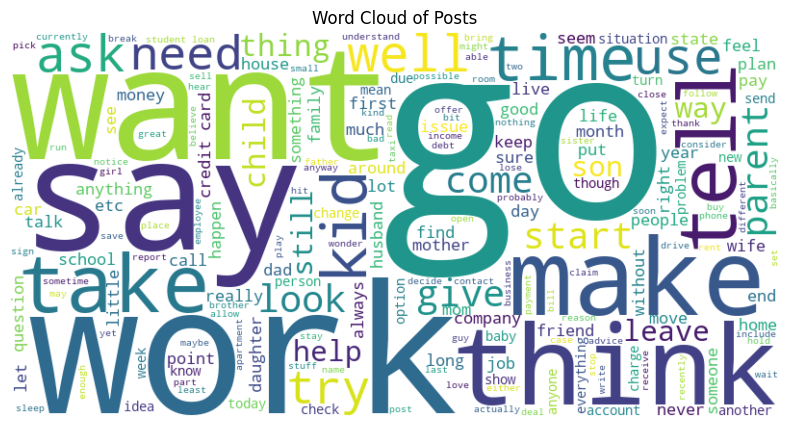

In [28]:
allposts = " ".join(awords)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(allposts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title('Word Cloud of Posts')
plt.show()

In [29]:
text.tail()

,subreddit,post,subreddit_id,extendedpost
19432,legaladvice,legality of anticop stickers and badges dkuk p...,0,Legality of anti-cop stickers and badges [DK/U...
19433,legaladvice,tshirt design theft i saw an awesome original ...,0,T-shirt design theft I saw an awesome original...
19434,legaladvice,company is penalizing people for using sick ti...,0,Company is penalizing people for using sick ti...
19435,legaladvice,abandoning uk debt as a us citizen i am lookin...,0,Abandoning UK debt as a US citizen I am lookin...
19436,legaladvice,lost friend in nashville i lost a friend in na...,0,Lost friend in Nashville I lost a friend in Na...


## **d) Clustering**

* Finance
* Parenting
* Legal Advice

In [35]:
vectorizer = TfidfVectorizer(max_features=15000, stop_words="english")
X = vectorizer.fit_transform(text["post"])

clustersnum = 3
kmeans = KMeans(n_clusters=clustersnum, random_state=42)
text["cluster"] = kmeans.fit_predict(X)

print("Cluster Centres (Top Words):")

# Extracting the top 10 words of each cluster
ordercentroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(clustersnum):
    top_words = [terms[ind] for ind in ordercentroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_words)}")

# Assign the nearest cluster to a new post
newpost = ["What to do? My wife left me before my military deployment  under the guise she was just visiting family but went to go live with her â€œgood friend(also military)â€  in another state with out telling me with my 3 yr old. She never told me she was moving and I only found out that she is staying after noticing some credit card charges in a different state than her family and confronting her about it. She has now decided to try and adopt her 17 yr old niece who currently shares a bedroom with my 3 yr old in the house with this good . This is not a favorable condition for my child in my opinion. I also give her informal  child support as of now because she has no job and no money. Iâ€™m going to file as soon I get back but I donâ€™t know how this is going to play out for myself and my child.  What should I do? "]
newpostvect = vectorizer.transform(newpost)
predicted_cluster = kmeans.predict(newpostvect)
print(f"The new post belongs to cluster {predicted_cluster[0]}")

Cluster Centers (Top Words):
Cluster 0: car, money, pay, just, account, ampx200b, company, work, job, year
Cluster 1: kids, just, old, son, like, daughter, time, child, year, does
Cluster 2: credit, card, score, debt, loan, pay, cards, balance, car, student
The new post belongs to cluster 1


# **1.4 Modelling**

## **a) Vectorization**

glove.6B.300d.txt is a pre-trained word embedding model used for word vectorization. It contains 6 billion words, which allows the data set to be rich representation of word semantics.

In [36]:
embedding_dim = 300

glovefilepath = r"C:\Users\cmanu\OneDrive\Escritorio\NCIDA\DATAMINING\DM_Project\TEXT\glove.6B.300d.txt"

glovevectors = {}
with open(glovefilepath, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glovevectors[word] = vector

print("Number of words in GloVe:", len(glovevectors))

Number of words in GloVe: 400000


In [37]:
def average_glovevector(text, glovevectors, embedding_dim=300):
    words = text.split()
    vectors = [glovevectors[word] for word in words if word in glovevectors]
    if len(vectors) == 0:
        return np.zeros(embedding_dim)
    return np.mean(vectors, axis=0)

## **b) Data set split**

In [38]:
X = np.array([average_glovevector(post, glovevectors, embedding_dim) for post in text["post"]])
y = text["subreddit_id"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(15549, 300) (15549,) (3888, 300) (3888,)


## **c) Models**

In [39]:
# Random Forest Classifier
rfclassifier = RandomForestClassifier(n_estimators=1000, random_state=42)
rfclassifier.fit(X_train, Y_train)
y_predrf = rfclassifier.predict(X_test)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, Y_train)
y_predlr = logreg.predict(X_test)

# **1.5 Evaluation**

### **a) Metrics**

In [60]:
# Random Forest
rfclassr = classification_report(Y_test, y_predrf, output_dict=True)
rf_report_df = pd.DataFrame(rfclassr).transpose()


#Logistic Regression
lrclassr = classification_report(Y_test, y_predlr, output_dict=True)
lr_report_df = pd.DataFrame(lrclassr).transpose()


### **b) Metrics Report**

In [61]:
allmetrics = pd.concat([rf_report_df, lr_report_df], keys=["Random Forest", "Logistic Regression"])
allmetrics

precision    recall  f1-score      support
Random Forest       0              0.849741  0.851632  0.850685  1348.000000
                    1              0.899096  0.929907  0.914242  1284.000000
                    2              0.908189  0.874204  0.890872  1256.000000
                    accuracy       0.884774  0.884774  0.884774     0.884774
                    macro avg      0.885675  0.885247  0.885267  3888.000000
                    weighted avg   0.884922  0.884774  0.884657  3888.000000
Logistic Regression 0              0.887097  0.897626  0.892330  1348.000000
                    1              0.945004  0.950156  0.947573  1284.000000
                    2              0.917275  0.900478  0.908799  1256.000000
                    accuracy       0.915895  0.915895  0.915895     0.915895
                    macro avg      0.916459  0.916087  0.916234  3888.000000
                    weighted avg   0.915969  0.915895  0.915894  3888.000000

### **c) Predicting category of post**

In [62]:
def predict_newpost(newposts, model, glovevectors, embedding_dim=300, label_encoder=None):
    new_text_vector = average_glovevector(newposts, glovevectors, embedding_dim)
    predicted_labelencoded = model.predict([new_text_vector])
    predictedlabel = labelenc.inverse_transform(predicted_labelencoded)
    return predictedlabel[0]

In [63]:
newposts = "Now I'm sitting here with no job, a pending loan payment on the 15th of about $300 dollars, roughly $400 in expenses in between then, and rent on the 1st at $1350"

# Choose the model you want to use for prediction (Random Forest or Logistic Regression)
predicted_rf = predict_newpost(newposts, rfclassifier, glovevectors, embedding_dim, labelenc)
predicted_lr = predict_newpost(newposts, logreg, glovevectors, embedding_dim, labelenc)

print("Predicted category using Random Forest:", predicted_rf)
print("Predicted category using Logistic Regression:", predicted_lr)

Predicted category using Random Forest: personalfinance
Predicted category using Logistic Regression: personalfinance
